In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Carga de datos procesados**

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_parquet("../data/processed/dataset.parquet")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2) Feature engineering

In [4]:
# agrupar por edad
df['age_group'] = pd.cut(df['age'], bins=[18,30,45,60,100], labels=['young','adult','mid','senior'])

In [5]:
# transformar la variable campaign usando logaritmo
df['campaign_log'] = np.log1p(df['campaign'])

In [6]:
# crear una nueva variable que indique si el cliente ha sido contactado antes
df['contacted_before'] = (df['previous'] > 0).astype(int)

In [7]:
# crear una variable que indique si el cliente ha sido contactado recientemente (en los últimos 30 días)
df['pdays_clean'] = df['pdays'].replace(999, np.nan)
df['recent_contact'] = (df['pdays_clean'] < 30).astype(int)

In [8]:
# crear una variable que indique si el cliente ha tenido éxito en la última campaña
df['prev_success'] = ((df['previous'] > 0) & (df['poutcome'] == 'success')).astype(int)

In [9]:
# crear una variable que indique si el cliente tiene alguna deuda (hipoteca o préstamo)
df['has_debt'] = ((df['housing'] == 'yes') | (df['loan'] == 'yes')).astype(int)

In [10]:
# crear una variable que indique la estación del año según el mes
def season(month):
    if month in ['dec','jan','feb']:
        return 'winter'
    elif month in ['mar','apr','may']:
        return 'spring'
    elif month in ['jun','jul','aug']:
        return 'summer'
    else:
        return 'fall'

df['season'] = df['month'].apply(season)

# **2) Split de datos (train/test)**

### Separación de variables predictoras (X) y variable objetivo (y, "has the client subscribed a term deposit?")

In [11]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'age_group', 'campaign_log',
       'contacted_before', 'pdays_clean', 'recent_contact', 'prev_success',
       'has_debt', 'season'],
      dtype='object')

In [14]:
df["pdays_clean"] = df["pdays_clean"].astype(float)
df["previous"] = df["previous"].astype(float)
df["campaign_log"] = df["campaign_log"].astype(float)

In [15]:
features = [
    'age',
    'job',
    'marital',
    'education',
    'balance',
    'housing',
    'loan',
    'contact',
    'season',          # o 'season' (elige solo una)
    'campaign_log',
    'pdays_clean',
    'previous',
    'poutcome',
    'prev_success',
]

In [16]:
# Separación de variables predictoras (X) y variable objetivo (y, "has the client subscribed a term deposit?")

X = df[features]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)    

# Checamos el shape de las variables de entreno y prueba X, Y
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(36168, 14)
(36168,)
(9043, 14)
(9043,)


**Observación**

En `x_features`, decidimos hacer un drop de las siguientes columnas:

1. `y` es nuestra variable target - has the client subscribed a term deposit?.
2. `duration` representa la duración de la última llamada telefónica realizada al cliente. A primera vista parece una variable predictora válida, sin embargo, es una variable trampa: solo se conoce una vez que la llamada ya ocurrió, lo cual se supone no debería de conocerse. Tmabién existe una relación directa con el target, ya que a mayor duración de la llamada, mayor probabilidad de que el cliente se suscriba, lo que introduce data leakage; el objetivo es predecir antes de realizar el contacto si un cliente suscribirá un depósito a plazo, duration es excluida del entrenamiento.
3. para las variables `day_of_week`,`month`, en el EDA encontramos que estas dos variables no generan un impacto relevante en la decisión del client de suscribir un depósito a largo plazo.

## **2.1 Pipeline: preprocesamiento + modelo (evitar data leakage)**

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               45211 non-null  int64   
 1   job               45211 non-null  object  
 2   marital           45211 non-null  object  
 3   education         45211 non-null  object  
 4   default           45211 non-null  object  
 5   balance           45211 non-null  int64   
 6   housing           45211 non-null  object  
 7   loan              45211 non-null  object  
 8   contact           45211 non-null  object  
 9   day               45211 non-null  int64   
 10  month             45211 non-null  object  
 11  duration          45211 non-null  int64   
 12  campaign          45211 non-null  int64   
 13  pdays             45211 non-null  int64   
 14  previous          45211 non-null  float64 
 15  poutcome          45211 non-null  object  
 16  y                 4521

In [19]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'age_group', 'campaign_log',
       'contacted_before', 'pdays_clean', 'recent_contact', 'prev_success',
       'has_debt', 'season'],
      dtype='object')

### **Clasificamos cada columna como numérica o categórica**

En nuestro archivo EDA, teníamos lo siguiente:

`X_bin = X[["default","housing","loan"]]` entonces vamos a mirar que tipo de encoder es el mejor approach.

In [20]:
print(f'Variable housing:{df["housing"].value_counts()}\n')
print(f'Variable loan:{df["loan"].value_counts()}\n')
print(f'Variable default:{df["default"].value_counts()}')

Variable housing:housing
yes    25130
no     20081
Name: count, dtype: int64

Variable loan:loan
no     37967
yes     7244
Name: count, dtype: int64

Variable default:default
no     44396
yes      815
Name: count, dtype: int64


In [21]:
numeric_features = [
    "age",
    "balance",
    "campaign_log",   # nueva (reemplaza campaign)
    "pdays_clean",    # nueva (reemplaza pdays)
    "previous"
]


categorical_features = [
    "job",
    "marital",
    "education",
    "contact",
    "season",        # o "month" (elige solo una)
    "poutcome"
]

binary_features = [
    "housing",
    "loan",
    "prev_success"   # nueva 🔥
]

### **Pipelines y transformaciones**

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from category_encoders import TargetEncoder



# Hacemos nuestra transformación de variables binarias a numéricas (0 y 1)
for col in binary_features:
    if X_train[col].dtype == "object":  # solo si es texto, así no se hace en 0 cuando ejecutamos el código otra vez
        X_train[col] = X_train[col].map({"yes": 1, "no": 0})
        X_test[col]  = X_test[col].map({"yes": 1, "no": 0})

# Checamos la distrbución para las features binarias
for col in binary_features:
    print(X_train[col].value_counts(), "\n")

housing
1    20182
0    15986
Name: count, dtype: int64 

loan
0    30355
1     5813
Name: count, dtype: int64 

prev_success
0    34963
1     1205
Name: count, dtype: int64 



In [23]:
df['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [24]:
# Transformers

# ---------------------------Transformadores---------------------------

numeric_transformer_lr = Pipeline(
    steps=[
    ("imputer", SimpleImputer(strategy="median")), # En nuestro EDA vimos que no hay nulos en las variable numéricas, pero por si acaso imputamos con la mediana
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")), # si hay un valor en tests que no estaba en train, lo reemplaza por Unknown
        ("encoder", TargetEncoder(smoothing=10)), # mezcla el promedio de categorías con el global
    ]
)
# Usamos TargetEnconder (la profe había usado Dicvectorizer) porque hay variables categóricas con muchas categorías, por ejemplo "job" y "poutcome" solo tiene 4 subcategorías

# ---------------------------Preprocesadores---------------------------

# Combinamos los transformadores usando ColumnTransformer, y dejamos las binarias tal cual (passthrough) porque ya las transformamos arriba

# ---Logistic Regression---
lr_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer_lr, numeric_features),  
    ("cat", categorical_transformer, categorical_features),  
], remainder="passthrough")

# ---Trees que son (RandomForrest Y XGBoost)---
tree_preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features),  # No hacemos escalado porque no hace falta en los trees
    ("cat", categorical_transformer, categorical_features),
], remainder="passthrough")  # binary_features pasan directo

# ---------------------------Pipelines (van dentro del mlflow---------------------------

neg_pos_ratio = (y_train == "no").sum() / (y_train == "yes").sum() # para XGBoost, no se puede escalar con class_weight, toca usar scale_pos_weight 

# scale_pos_weight = "It controls the balance of positive and negative weights" y como nuestra base esta desbalanceada, le decimos a XGBoost que le de más peso a la clase chica que es "yes" -> https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning

  

## **Entrenar: levantamos el MLflow Tracking Server**

```bash
mlflow server \
  --host 127.0.0.1 \
  --port 5001 \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlruns
```
Opción que me funcionó con Powershell
```powershell
mlflow server `
  --host 127.0.0.1 `
  --port 5001 `
  --backend-store-uri sqlite:///mlflow.db `
  --default-artifact-root ./mlruns
```

`Puerto: http://127.0.0.1:5001`

Y se crea el file `mlflow.db`

In [25]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5001")
print(f"tracking URI: '{mlflow.get_tracking_uri()}'")

tracking URI: 'http://127.0.0.1:5001'


In [102]:
#mlflow.search_experiments()

### **Para LogisticRegression**

1. Vamos a usar principalmente las metricas de roc_auc_score por el desbalance de nuestra variable target y el f1_score

2. Usamos como uno de los parámetros `C` -> 

- C is like your way of telling this machine how much attention to pay to these details. A high C means you're encouraging the machine to take every little detail seriously, aiming for perfection
- a low C is like advising the machine to take a step back and not to obsess over every small detail.

In [46]:
import optuna
import numpy as np
import mlflow
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, roc_auc_score,
    accuracy_score, precision_score, recall_score
)

# 🔥 función para encontrar mejor threshold
def find_best_threshold(y_true, y_proba):
    thresholds = np.linspace(0.1, 0.9, 50)
    best_threshold = 0.5
    best_f1 = 0

    for t in thresholds:
        y_pred = np.where(y_proba >= t, "yes", "no")
        f1 = f1_score(y_true, y_pred, pos_label="yes")

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    return best_threshold, best_f1


mlflow.set_experiment("bank-marketing-lr-optuna")
mlflow.autolog()


def objective_lr(trial):
    
    C = trial.suggest_float("C", 1e-3, 10.0, log=True)
    max_iter = trial.suggest_categorical("max_iter", [200, 300])

    pipeline_lr = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("smote", SMOTE(random_state=42)),  # 🔥 NUEVO
        ("model", LogisticRegression(
            C=C,
            max_iter=max_iter,
            random_state=42
        ))
    ]
)

    with mlflow.start_run(
        run_name=f"lr_c{C}_iter{max_iter}_trial.{trial.number}",
        nested=True
    ) as run:

        trial.set_user_attr("mlflow_run_id", run.info.run_id)

        # 🔖 tags
        mlflow.set_tag("problem_type", "classification")
        mlflow.set_tag("model_family", "logistic_regression")
        mlflow.set_tag("dataset", "bank_marketing")
        mlflow.set_tag(
            "features",
            ",".join(numeric_features + categorical_features + binary_features)
        )
        mlflow.set_tag("optimization", "optuna")

        # 🧠 entrenamiento
        pipeline_lr.fit(X_train, y_train)

        # 🔥 probabilidades
        y_proba = pipeline_lr.predict_proba(X_test)[:, 1]

        # 🔥 threshold tuning
        best_t, best_f1 = find_best_threshold(y_test, y_proba)

        # 🔥 predicción optimizada
        y_pred_lr = np.where(y_proba >= best_t, "yes", "no")

        # 📊 métricas
        accuracy = accuracy_score(y_test, y_pred_lr)
        precision = precision_score(y_test, y_pred_lr, pos_label="yes")
        recall = recall_score(y_test, y_pred_lr, pos_label="yes")
        f1 = best_f1
        auc = roc_auc_score(y_test, y_proba)

        # 📦 log metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_opt", f1)
        mlflow.log_metric("auc", auc)

        # 🔥 log threshold
        mlflow.log_param("best_threshold", best_t)

        return f1


# 🔬 optimización
study_lr = optuna.create_study(direction="maximize")

with mlflow.start_run(run_name="optuna_study_lr") as parent_run:

    mlflow.set_tag("stage", "hpo")

    study_lr.optimize(objective_lr, n_trials=10)

    # 🔝 top trials
    top_trials = sorted(
        [t for t in study_lr.trials if t.value is not None],
        key=lambda t: t.value,
        reverse=True
    )[:5]

    top_trials_data = [
        {
            "trial_number": t.number,
            "f1": t.value,
            "params": t.params,
            "mlflow_run_id": t.user_attrs.get("mlflow_run_id")
        }
        for t in top_trials
    ]

    # 🏆 mejores params
    best_params = study_lr.best_params

    mlflow.log_params(best_params)
    mlflow.log_metric("best_f1", study_lr.best_value)
    mlflow.log_dict(top_trials_data, "optuna_top_trials.json")
    mlflow.log_dict(best_params, "optuna_best_params.json")


# 📢 resultados
print(f"Parent run id: {parent_run.info.run_id}")
print(f"Best params: {study_lr.best_params}")
print(f"Best F1: {study_lr.best_value}")
print(f"Best trial: {study_lr.best_trial.number}")
print(f"Best trial MLflow run id: {study_lr.best_trial.user_attrs.get('mlflow_run_id')}")

2026/04/13 01:30:23 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/04/13 01:30:23 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/04/13 01:30:23 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
[I 2026-04-13 01:30:23,149] A new study created in memory with name: no-name-af2a4ea9-6410-4f7d-86cf-da96dc6f0305
2026/04/13 01:30:23 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that i

🏃 View run lr_c7.99133235985429_iter300_trial.0 at: http://127.0.0.1:5001/#/experiments/1/runs/34d33d0c83fa45ea91f428e96a21eac5
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/13 01:30:56 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/13 01:30:56 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\

🏃 View run lr_c0.05671128229889743_iter200_trial.1 at: http://127.0.0.1:5001/#/experiments/1/runs/7f60fff3655846af87a3d6ccfc95191b
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/13 01:31:26 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/13 01:31:26 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\

...

🏃 View run lr_c0.0035217787058567022_iter200_trial.7 at: http://127.0.0.1:5001/#/experiments/1/runs/afecdf45c0be4a1aba67f552b16913c0
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/13 01:34:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/13 01:34:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\

🏃 View run lr_c0.0013657259624188583_iter300_trial.8 at: http://127.0.0.1:5001/#/experiments/1/runs/3bf5c2ec6f0a4165ae903e47a5c915c1
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/13 01:35:28 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/13 01:35:28 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\

🏃 View run lr_c0.4391958804963258_iter300_trial.9 at: http://127.0.0.1:5001/#/experiments/1/runs/de5133b6792d41d6b7adf74b2ec1dca1
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
🏃 View run optuna_study_lr at: http://127.0.0.1:5001/#/experiments/1/runs/6809b4e508e1454f81c7ddca1322d97c
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
Parent run id: 6809b4e508e1454f81c7ddca1322d97c
Best params: {'C': 0.05671128229889743, 'max_iter': 200}
Best F1: 0.38997214484679665
Best trial: 1
Best trial MLflow run id: 7f60fff3655846af87a3d6ccfc95191b


In [47]:
# Analizar el mejor trial

print(f"Best trial: {study_lr.best_trial.number}")
print(f"Best value (f1): {study_lr.best_value:.4f}")
print("Best params:")
for key, value in study_lr.best_params.items():
    print(f"  {key}: {value}")

# Train the best model (retrain)
best_params = {**study_lr.best_params, "class_weight": "balanced", "random_state": 42}
best_model = LogisticRegression(**best_params)

best_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("model", LogisticRegression(**best_params))
    ]
)

best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

f1_best = f1_score(y_test, y_pred_best, pos_label="yes")
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, pos_label="yes")
recall_best = recall_score(y_test, y_pred_best, pos_label="yes")
auc_best = roc_auc_score(y_test, y_proba_best)

print(f"\nBest model F1: {f1_best:.4f}")
print(f"Best model Accuracy: {accuracy_best:.4f}")
print(f"Best model Precision: {precision_best:.4f}")
print(f"Best model Recall: {recall_best:.4f}")
print(f"Best model AUC: {auc_best:.4f}")

2026/04/13 01:36:08 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3c252f835f29443a9584b6c26e97cde5', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Best trial: 1
Best value (f1): 0.3900
Best params:
  C: 0.05671128229889743
  max_iter: 200


2026/04/13 01:36:09 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/13 01:36:09 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\

🏃 View run rambunctious-ant-876 at: http://127.0.0.1:5001/#/experiments/1/runs/3c252f835f29443a9584b6c26e97cde5
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/13 01:36:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 01:36:16 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 01:36:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 01:36:23 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '978a176032ef47d58a988e66133735e6', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/13 01:36:23 WARNING mlflow.sklearn: 

🏃 View run caring-turtle-505 at: http://127.0.0.1:5001/#/experiments/1/runs/1e5851829c3446b89b0880e3e9e7aa28
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/13 01:36:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 01:36:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 01:36:30 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded 

🏃 View run melodic-pig-748 at: http://127.0.0.1:5001/#/experiments/1/runs/978a176032ef47d58a988e66133735e6
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/13 01:36:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."



Best model F1: 0.3446
Best model Accuracy: 0.7174
Best model Precision: 0.2365
Best model Recall: 0.6352
Best model AUC: 0.7438


**Observación**

Para el primer experimento, con `parent run id = 9525cccbd173408ba60cdec9fab05c29`, podemos concluir que:

1. el mejor trial es el 5 -- 02ead421159c4530bf22df4f6f19147f
2. Best value (f1): 0.3331
3. Best params: C: 0.34616776365583773 y max_iter: 500

El modelo presenta un desempeño aceptable en términos de `accuracy`; sin embargo, dado que la variable objetivo está desbalanceada, esta métrica por sí sola puede resultar engañosa ("no" es el 88.30% y el "yes" el 11.70%). También muestra una capacidad razonable para discriminar entre las clases "Yes" y "No" con ese `AUC = 0.7297`.

Además, el modelo logra identificar una proporción considerable de los clientes que sí se suscriben (`recall = 62%`). No obstante, la `precision` es baja, lo que indica un número elevado de falsos positivos. Esto sugiere que el modelo tiende a sobreestimar la clase positiva, posiblemente influido por el uso de `class_weight="balanced"`.


**Visualizando la optimización de optuna para LR**

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_23984\2547692028.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_lr)


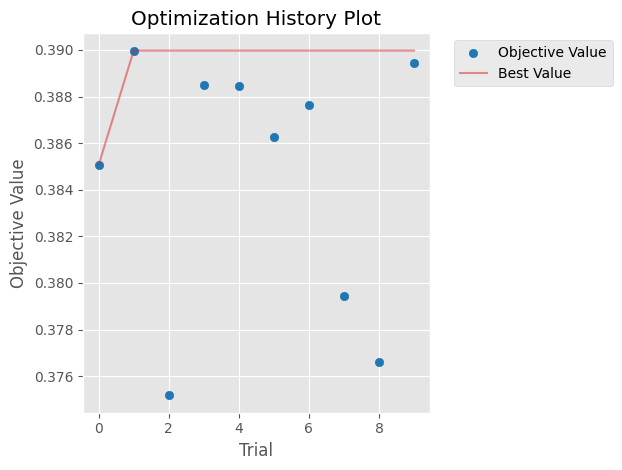

In [48]:
# Visualize optimization history
import matplotlib.pyplot as plt


# Optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_lr)
plt.show()

### **Funciones**:

Creamos las siguientes funcionespara trabajar más rápido y aplicar la misma lógica a modelos como Random Forest y XGBoost, y no repetir todo lo mismo que hicimos en lr.

In [39]:
def evaluate_classification_model(pipeline, X_train, y_train, X_test, y_test, pos_label=1):
    pipeline.fit(X_train, y_train)

# a la función pipeline le paso el modelo que vayamos a usar (lr, rf o xgboost)
# pasamos los datos para entrenar x_train y el y_train
# lo mismo con los de evaluar

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

# el diccionario de métricas
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label= pos_label),
        "recall": recall_score(y_test, y_pred, pos_label= pos_label),
        "f1": f1_score(y_test, y_pred, pos_label= pos_label),
        "auc": roc_auc_score(y_test, y_proba),
    }

    return y_pred, y_proba, metrics

# las métricas con el log
def log_classification_metrics(metrics):
    mlflow.log_metric("accuracy", metrics["accuracy"])
    mlflow.log_metric("precision", metrics["precision"])
    mlflow.log_metric("recall", metrics["recall"])
    mlflow.log_metric("f1_yes_manual", metrics["f1"])
    mlflow.log_metric("auc_manual", metrics["auc"])

# top_trails del study

def get_top_trials_data(study, top_n=5, metric_name="f1"):
    top_trials = sorted(
        [t for t in study.trials if t.value is not None],
        key=lambda t: t.value,
        reverse=True
    )[:top_n]

    top_trials_data = [
        {
            "trial_number": t.number,
            metric_name: t.value,
            "params": t.params,
            "mlflow_run_id": t.user_attrs.get("mlflow_run_id")
        }
        for t in top_trials
    ]

    return top_trials_data


### **Para RandomForestClassifier**


In [51]:
mlflow.set_experiment("bank-marketing-rf-optuna")
mlflow.autolog()

def objective_rf(trial):
    n_estimators = trial.suggest_categorical("n_estimators", [200, 300, 500])
    max_depth = trial.suggest_categorical("max_depth", [5, 10, 15]) 

# Creamos el Pipeline y usamos el preprocesador de regresión logística
    pipeline_rf = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            #("smote", SMOTE(random_state=42)),
            ("model", RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ]
    )
# Abrimos el run de mloflow para el trial que creamos de optuna (de la función objetivo)
# en esta ocasión metí el entrenamiento y las predicciones dentro del with mlflow.start_run 
    with mlflow.start_run(run_name=f"rf_n_estimators{n_estimators}_max_depth{max_depth}_trial.{trial.number}", nested=True) as run:
        trial.set_user_attr("mlflow_run_id", run.info.run_id)
        mlflow.set_tag("problem_type", "classification")
        mlflow.set_tag("model_family", "random_forest")
        mlflow.set_tag("dataset", "bank_marketing")
        mlflow.set_tag(
            "features",
            ",".join(numeric_features + categorical_features + binary_features)
        )
        mlflow.set_tag("optimization", "optuna")

        # Entrenamos el modelo, las predicciones y la prob
        y_pred_rf, y_proba_rf, metrics = evaluate_classification_model(
            pipeline_rf, X_train, y_train, X_test, y_test, pos_label="yes"
        )

        # Nuestras métricas, para mlflow y f1 retornado para optuna
        log_classification_metrics(metrics)

        return metrics["f1"]  # accedemos a f1 

# ya en el studio le digo que queremos hacer esa optimización con optuna, con esa métrica que retornó la función objetivo
study_rf= optuna.create_study(direction="maximize")

with mlflow.start_run(run_name="optuna_study_rf") as parent_run:  # nuestra carpeta padre del proceso
    mlflow.set_tag("stage", "hpo")
    study_rf.optimize(objective_rf, n_trials=10)

    top_trials_data = get_top_trials_data(study_rf, top_n=5, metric_name="f1")

    # Best params
    best_params = study_rf.best_params

    mlflow.log_params(best_params)
    mlflow.log_metric("best_f1", study_rf.best_value)
    mlflow.log_dict(top_trials_data, "optuna_top_trials.json") # Guardar como artifacts
    mlflow.log_dict(best_params, "optuna_best_params.json") # Guardar como artifacts

print(f"Parent run id: {parent_run.info.run_id}")
print(f"Best params: {study_rf.best_params}")
print(f"Best F1: {study_rf.best_value}")
print(f"Best trial: {study_rf.best_trial.number}")
print(f"Best trial MLflow run id: {study_rf.best_trial.user_attrs.get('mlflow_run_id')}")



2026/04/13 01:50:20 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/04/13 01:50:20 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/04/13 01:50:20 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
[I 2026-04-13 01:50:20,623] A new study created in memory with name: no-name-af19937c-0810-4aea-9e5e-a2ebacbf4b2f
2026/04/13 01:50:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 01:50:21 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 01:50:24 WARNING mlflow.utils.environment: Failed to resolve install

🏃 View run rf_n_estimators300_max_depth10_trial.0 at: http://127.0.0.1:5001/#/experiments/2/runs/ff7b17b2a06c4fb7a633af12490f5cfc
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/13 01:50:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 01:50:32 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 01:50:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 01:50:36 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/13 01:50:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because thes

🏃 View run rf_n_estimators200_max_depth15_trial.1 at: http://127.0.0.1:5001/#/experiments/2/runs/b1f7221797a54da2a5ba377d43d50ec0
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/13 01:50:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 01:50:43 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 01:50:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 01:50:47 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/13 01:50:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because thes

...

🏃 View run rf_n_estimators300_max_depth10_trial.7 at: http://127.0.0.1:5001/#/experiments/2/runs/e71c83d5772240919707d5d2b3171cea
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/13 01:51:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 01:51:49 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 01:51:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 01:51:52 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/13 01:51:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because thes

🏃 View run rf_n_estimators300_max_depth10_trial.8 at: http://127.0.0.1:5001/#/experiments/2/runs/9ffe5b7ec1bf4a289ccd030dcc8a4e70
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/13 01:52:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 01:52:00 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 01:52:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 01:52:03 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/13 01:52:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because thes

🏃 View run rf_n_estimators500_max_depth10_trial.9 at: http://127.0.0.1:5001/#/experiments/2/runs/337f53abce9741438786925133f060cf
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
🏃 View run optuna_study_rf at: http://127.0.0.1:5001/#/experiments/2/runs/066e21738011428ea9c670688db423f1
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
Parent run id: 066e21738011428ea9c670688db423f1
Best params: {'n_estimators': 200, 'max_depth': 15}
Best F1: 0.4085637823371989
Best trial: 1
Best trial MLflow run id: b1f7221797a54da2a5ba377d43d50ec0


In [57]:
# Analizar el mejor trial

print(f"Best trial: {study_rf.best_trial.number}")
print(f"Best value (f1): {study_rf.best_value:.4f}")
print("Best params:")
for key, value in study_rf.best_params.items():
    print(f"  {key}: {value}")

# Train the best model (retrain)
best_params = {**study_rf.best_params, "class_weight": "balanced", "random_state": 42}
best_model = RandomForestClassifier(**best_params)

best_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("model", RandomForestClassifier(**best_params))
    ]
)

best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

f1_best = f1_score(y_test, y_pred_best, pos_label="yes")
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, pos_label="yes")
recall_best = recall_score(y_test, y_pred_best, pos_label="yes")
auc_best = roc_auc_score(y_test, y_proba_best)

print(f"\nBest model F1: {f1_best:.4f}")
print(f"Best model Accuracy: {accuracy_best:.4f}")
print(f"Best model Precision: {precision_best:.4f}")
print(f"Best model Recall: {recall_best:.4f}")
print(f"Best model AUC: {auc_best:.4f}")

2026/04/13 02:03:16 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '0ae7224de7fe4167995b6ad3564db08e', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Best trial: 1
Best value (f1): 0.4086
Best params:
  n_estimators: 200
  max_depth: 15


2026/04/13 02:03:16 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/13 02:03:16 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\

🏃 View run serious-boar-770 at: http://127.0.0.1:5001/#/experiments/3/runs/0ae7224de7fe4167995b6ad3564db08e
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/13 02:03:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 02:03:20 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 02:03:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 02:03:24 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '8d0861104c214df69a71e4c0b9e56ef9', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/13 02:03:24 WARNING mlflow.sklearn: 

🏃 View run lyrical-jay-271 at: http://127.0.0.1:5001/#/experiments/3/runs/fcac502b860e4700b573952cfae91232
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/13 02:03:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 02:03:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 02:03:36 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded 

🏃 View run ambitious-shrew-793 at: http://127.0.0.1:5001/#/experiments/3/runs/8d0861104c214df69a71e4c0b9e56ef9
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/13 02:03:37 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."



Best model F1: 0.4093
Best model Accuracy: 0.8535
Best model Precision: 0.3873
Best model Recall: 0.4338
Best model AUC: 0.7606


**Observación**

Para el primer experimento, con `parent run id = 81dc9dda53de42fdaa77a7c22d01a216`, podemos concluir que:

1. el mejor trial es el 7 -- 89f92ab86aad43cb9f48687d15e13698
2. Best value (f1): 0.3849
3. Best params: n_estimators: 500 y max_depth: 15

El modelo presenta un desempeño aceptable en términos de `accuracy`; sin embargo, dado que la variable objetivo está desbalanceada, esta métrica por sí sola puede resultar engañosa ("no" es el 88.30% y el "yes" el 11.70%). También muestra una capacidad razonable para discriminar entre las clases "Yes" y "No" con ese `AUC = 0.7215`.

Además, el modelo logra identificar una proporción moderada de los clientes que sí se suscriben (`recall = 40%`). No obstante, la `precision` mejora frente al modelo anterior, lo que indica una menor proporción de falsos positivos.



In [64]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline_rf_final = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=best_params["n_estimators"],
            max_depth=best_params["max_depth"],
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [66]:
y_pred_rf, y_proba_rf, metrics_rf = evaluate_classification_model(
    pipeline_rf_final,
    X_train, y_train,
    X_test, y_test,
    pos_label="yes"
)

2026/04/13 02:17:41 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'bb64b32887274b96ab17e3edcd977889', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/13 02:17:41 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. Se

🏃 View run loud-robin-94 at: http://127.0.0.1:5001/#/experiments/3/runs/bb64b32887274b96ab17e3edcd977889
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/13 02:17:48 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/13 02:17:48 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\

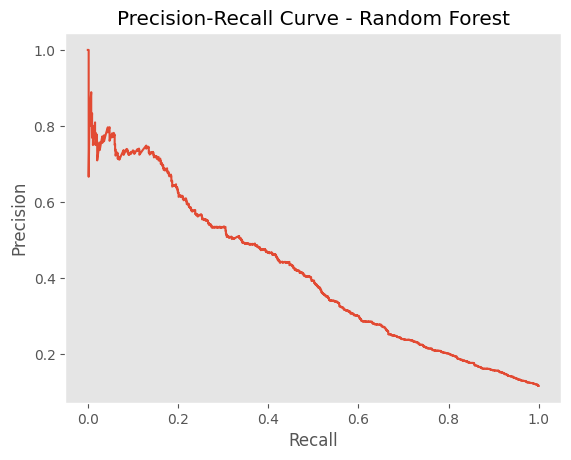

In [71]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_test_num = y_test.map({"no": 0, "yes": 1})

precision, recall, thresholds = precision_recall_curve(y_test_num, y_proba_rf)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.grid()
plt.show()

In [70]:
f1_scores = 2 * (precision * recall) / (precision + recall)

best_idx = f1_scores.argmax()

print("Best threshold:", thresholds[best_idx])
print("Best F1:", f1_scores[best_idx])

Best threshold: 0.1749195778679302
Best F1: 0.444967074317968


**Visualizando la optimización de optuna para LR**

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_23984\937943704.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_rf)


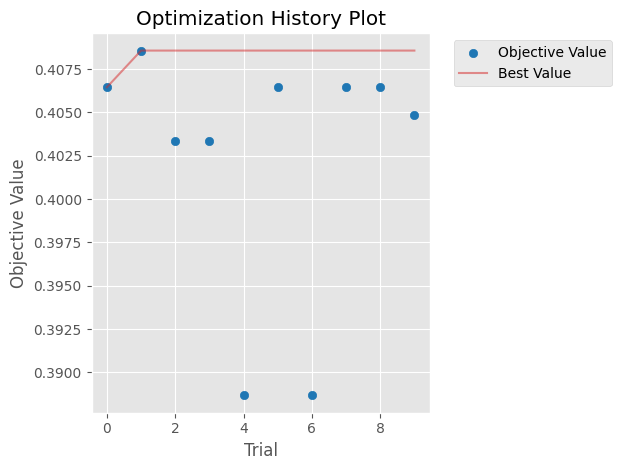

In [58]:
# Visualize optimization history
import matplotlib.pyplot as plt


# Optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_rf)
plt.show()

### **Para XGBClassifier**

In [60]:
# Target codificado para XGBoost
y_train_xgb = y_train.map({"no": 0, "yes": 1})
y_test_xgb = y_test.map({"no": 0, "yes": 1})

mlflow.set_experiment("bank-marketing-xgb-optuna")
mlflow.autolog()

def objective_xgb(trial):
    n_estimators = trial.suggest_categorical("n_estimators", [200, 300, 500])
    learning_rate = trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1])
    max_depth = trial.suggest_categorical("max_depth", [3, 5, 7])
    subsample = trial.suggest_categorical("subsample", [0.8, 1.0])

    pipeline_xgb = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", XGBClassifier(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                subsample=subsample,
                #eval_metric="auc",
                eval_metric="logloss",
                scale_pos_weight=round(neg_pos_ratio, 2),
                random_state=42,
                
            ))
        ]
    )

    with mlflow.start_run(
        run_name=f"xgb_n{n_estimators}_lr{learning_rate}_depth{max_depth}_trial.{trial.number}",
        nested=True
    ) as run:
        trial.set_user_attr("mlflow_run_id", run.info.run_id)

        mlflow.set_tag("problem_type", "classification")
        mlflow.set_tag("model_family", "xgboost")
        mlflow.set_tag("dataset", "bank_marketing")
        mlflow.set_tag(
            "features",
            ",".join(numeric_features + categorical_features + binary_features)
        )
        mlflow.set_tag("optimization", "optuna")

        _, _,  metrics = evaluate_classification_model(
            pipeline_xgb, X_train, y_train_xgb, X_test, y_test_xgb, pos_label=1
        )

        log_classification_metrics(metrics)

        return metrics["f1"]
    
study_xgb = optuna.create_study(direction="maximize")

with mlflow.start_run(run_name="optuna_study_xgb") as parent_run:
    mlflow.set_tag("stage", "hpo")
    study_xgb.optimize(objective_xgb, n_trials=10)

    top_trials_data = get_top_trials_data(study_xgb, top_n=5, metric_name="f1")

    best_params = study_xgb.best_params

    mlflow.log_params(best_params)
    mlflow.log_metric("best_f1", study_xgb.best_value)
    mlflow.log_dict(top_trials_data, "optuna_top_trials_xgb.json")
    mlflow.log_dict(best_params, "optuna_best_params_xgb.json")

print(f"Parent run id: {parent_run.info.run_id}")
print(f"Best params: {study_xgb.best_params}")
print(f"Best F1: {study_xgb.best_value}")
print(f"Best trial: {study_xgb.best_trial.number}")
print(f"Best trial MLflow run id: {study_xgb.best_trial.user_attrs.get('mlflow_run_id')}")
       


2026/04/13 02:07:30 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/04/13 02:07:30 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/04/13 02:07:30 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
[I 2026-04-13 02:07:30,382] A new study created in memory with name: no-name-64b6145c-a725-4ab6-acd5-cbabd90d7659
2026/04/13 02:07:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 02:07:30 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 02:07:34 WARNING mlflow.utils.environment: Failed to resolve install

🏃 View run xgb_n500_lr0.1_depth3_trial.0 at: http://127.0.0.1:5001/#/experiments/3/runs/80fb6b9402874df7bb74fd5cfd559f91
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/13 02:08:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 02:08:16 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 02:08:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 02:08:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 02:08:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-13 02:08:2

🏃 View run xgb_n200_lr0.01_depth7_trial.1 at: http://127.0.0.1:5001/#/experiments/3/runs/8f5717a37114401ea1028b6e68042ea6
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/13 02:08:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 02:08:26 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 02:08:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 02:08:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 02:08:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-13 02:08:3

...

🏃 View run xgb_n300_lr0.05_depth3_trial.7 at: http://127.0.0.1:5001/#/experiments/3/runs/2ca05e83de5f40fe9ff34b5dc317c43b
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/13 02:10:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 02:10:26 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 02:10:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 02:10:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 02:10:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-13 02:10:3

🏃 View run xgb_n500_lr0.01_depth3_trial.8 at: http://127.0.0.1:5001/#/experiments/3/runs/a514b90b4d21463ea6268b74cff5614b
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/13 02:10:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 02:10:36 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 02:10:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 02:10:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 02:10:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-13 02:10:4

🏃 View run xgb_n300_lr0.05_depth3_trial.9 at: http://127.0.0.1:5001/#/experiments/3/runs/458053fcb29445efa3b52464006fc51c
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3
🏃 View run optuna_study_xgb at: http://127.0.0.1:5001/#/experiments/3/runs/d56e5ceb6521474fa710d3932e64836f
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3
Parent run id: d56e5ceb6521474fa710d3932e64836f
Best params: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}
Best F1: 0.4008922880815806
Best trial: 4
Best trial MLflow run id: d36e4bac8d194ae180938c55cbba1cd4


In [61]:
best_params = {
    **study_xgb.best_params,
    "eval_metric": "auc",
    "scale_pos_weight": round(neg_pos_ratio, 2),
    "random_state": 42
}

best_pipeline_xgb = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", XGBClassifier(**best_params))
    ]
)

y_pred_best_xgb, y_proba_best_xgb, metrics_best_xgb = evaluate_classification_model(
    best_pipeline_xgb, X_train, y_train_xgb, X_test, y_test_xgb, pos_label=1
)

print(f"Best model F1: {metrics_best_xgb['f1']:.4f}")
print(f"Best model Accuracy: {metrics_best_xgb['accuracy']:.4f}")
print(f"Best model Precision: {metrics_best_xgb['precision']:.4f}")
print(f"Best model Recall: {metrics_best_xgb['recall']:.4f}")
print(f"Best model AUC: {metrics_best_xgb['auc']:.4f}")


2026/04/13 02:11:48 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '70b3e4caa67b46bd9e6f441752f5a593', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/13 02:11:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 02:11:49 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/13 02:11:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/13 02:11:53 INFO mlflow.utils.autolo

🏃 View run worried-ox-212 at: http://127.0.0.1:5001/#/experiments/3/runs/70b3e4caa67b46bd9e6f441752f5a593
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/13 02:11:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 02:11:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run victorious-rat-748 at: http://127.0.0.1:5001/#/experiments/3/runs/02e0879c1bef413e96ae15da5b339b56
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3
Best model F1: 0.4009
Best model Accuracy: 0.7921
Best model Precision: 0.3024
Best model Recall: 0.5945
Best model AUC: 0.7721


**Observación**

Para el experimento con `XGBoost`, con `parent run id = cb0281a1ea03451a84ce3cfa2c4c0476`, podemos concluir que:

1. el mejor trial es el 2 -- 2522dcc54b8b4a9eb93d7f247f93393c
2. Best value (f1): 0.400
3. Best params: n_estimators: 300, learning_rate: 0.01, max_depth: 5 y subsample: 1.0

El modelo presenta un desempeño aceptable en términos de `accuracy`; sin embargo, dado que la variable objetivo está desbalanceada, esta métrica por sí sola puede resultar engañosa ("no" es el 88.30% y el "yes" el 11.70%). También muestra una capacidad razonable para discriminar entre las clases "Yes" y "No" con ese `AUC = 0.7473`.

Además, el modelo logra identificar una proporción considerable de los clientes que sí se suscriben (`recall = 56%`). No obstante, la `precision` sigue siendo baja, lo que indica una proporción importante de falsos positivos. Esto sugiere que el modelo mantiene una capacidad relativamente buena para detectar la clase positiva, posiblemente favorecido por el uso de `scale_pos_weight` para manejar el desbalance de clases.
